#Latar Belakang
Peningkatan aktivitas industri, transportasi, serta pertumbuhan populasi yang pesat telah menyebabkan peningkatan signifikan terhadap tingkat pencemaran udara di berbagai wilayah. Salah satu polutan udara utama yang menjadi perhatian adalah Nitrogen Dioksida (NO₂), yaitu gas beracun yang dihasilkan terutama dari proses pembakaran bahan bakar fosil seperti kendaraan bermotor, pembangkit listrik, dan kegiatan industri. NO₂ memiliki dampak serius terhadap kesehatan manusia, seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk penyakit asma dan bronkitis. Selain itu, NO₂ juga berkontribusi terhadap pembentukan hujan asam dan penurunan kualitas lingkungan secara keseluruhan.

#1. Pengumpulan Data  

Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Bangkalan. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/ , buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html .

Untuk menuliskan code Python untuk mengambil data, silahkan kunjungi halaman https://dataspace.copernicus.eu/analyse/jupyterlab, klik Access JupyterLab, scroll kebawah sedikit …, lalu pilih Python 3 (ipykernel)

In [1]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
import openeo

In [4]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=BDHT-AHSC 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [21]:
aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [112.780, -7.228],
                        [112.785, -7.228],
                        [112.785, -7.232],
                        [112.780, -7.232],
                        [112.780, -7.228]
                    ]
                ]
            }
        }
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-01-01", "2026-06-01"],
    spatial_extent={
        "west": 112.780,
        "south": -7.232,
        "east": 112.785,
        "north": -7.228
    },
    bands=["NO2"],
)

# Agregasi harian untuk menghindari data ganda per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan data deret waktu (timeseries) rata-rata area
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [22]:
job = s5post.execute_batch(title="NO2 in bulak setro", outputfile="NO2bulaksetro.nc")

0:00:00 Job 'j-260603012940492893528fd051228bf9': send 'start'
0:00:18 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:00:23 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:00:29 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:00:38 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:00:48 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:01:00 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:01:16 Job 'j-260603012940492893528fd051228bf9': queued (progress 0%)
0:01:35 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:01:59 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:02:29 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:03:07 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:03:54 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:04:52 Job 'j-260603012940492893528fd051228bf9': running (progress N/A)
0:

In [24]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.6 MB/s eta 0:00:00


In [25]:
import netCDF4

file_path = "NO2bulaksetro.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
514
1
1
--


In [26]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [28]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

In [29]:
df = pd.DataFrame({
    "date": dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_bulaksetro_timeseries.csv", index=False)

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_bulaksetro_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-01-01"
end_date = "2025-06-01"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 2
Daftar tanggal missing:
DatetimeIndex(['2025-01-30', '2025-01-31'], dtype='datetime64[ns]', freq='D')


In [31]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2025-01-01", end="2025-06-01", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

/tmp/ipykernel_7895/3467833886.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 3
         date       NO2
78 2025-03-20  0.000135
79 2025-03-21  0.000146
80 2025-03-22  0.000134


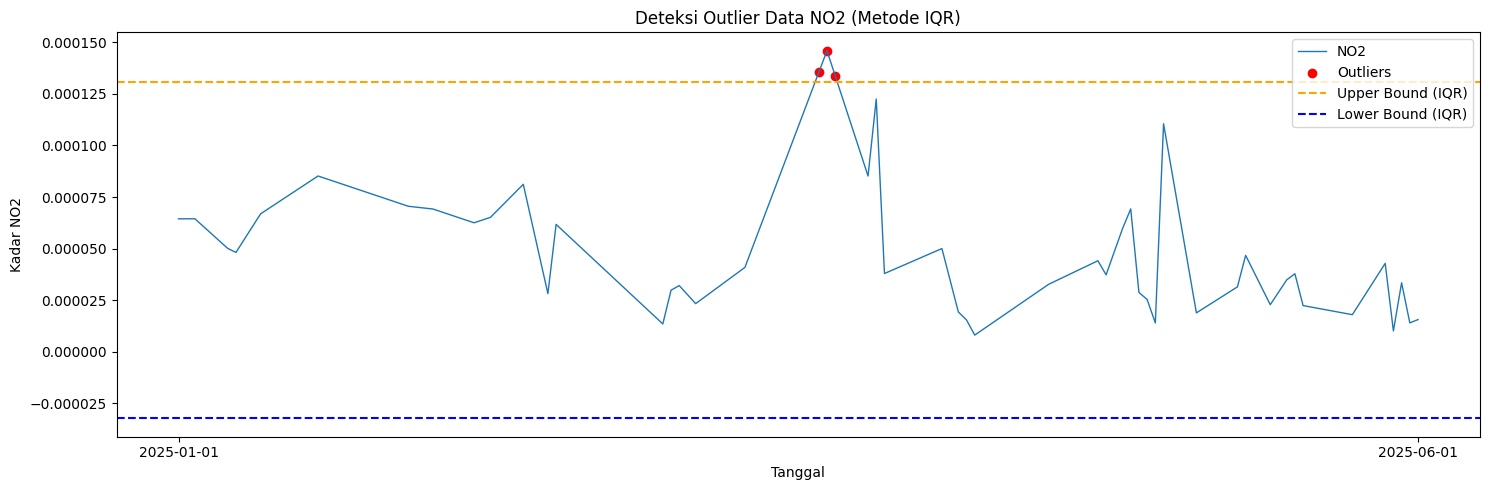

In [33]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [34]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 3
Jumlah missing setelah interpolasi: 0


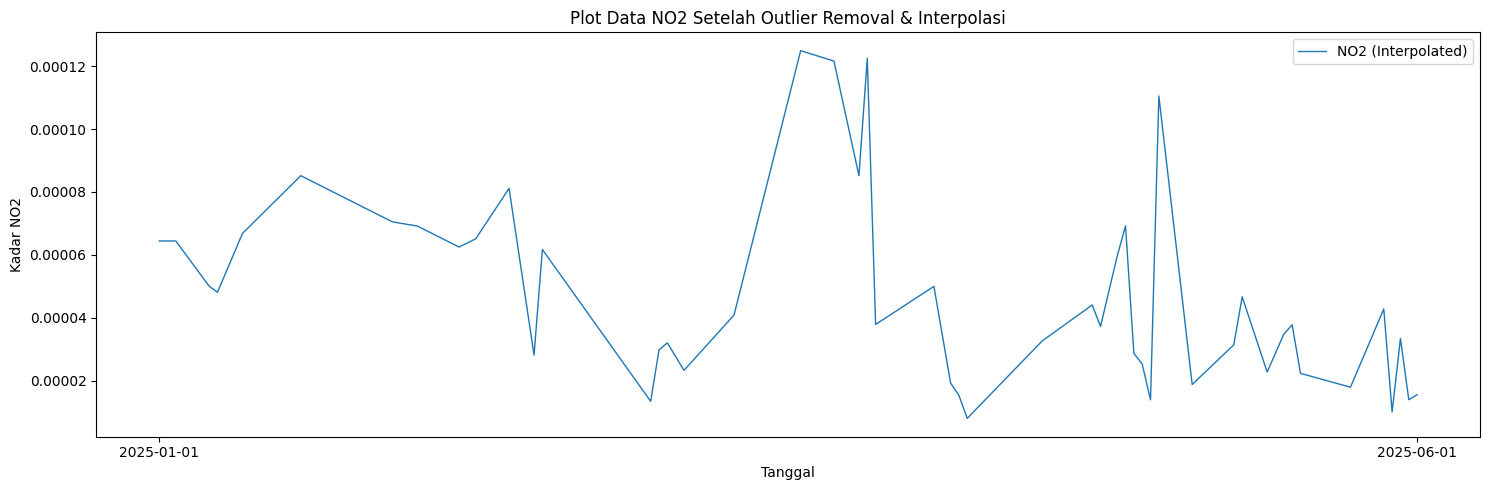

In [35]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# contoh penggunaan
supervised_df30 = create_supervised(df['NO2_filled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)   -0.013835
NO2(t-29)   -0.058134
NO2(t-28)   -0.130163
NO2(t-27)   -0.154648
NO2(t-26)   -0.204734
NO2(t-25)   -0.237503
NO2(t-24)   -0.264372
NO2(t-23)   -0.299160
NO2(t-22)   -0.316913
NO2(t-21)   -0.327125
NO2(t-20)   -0.322302
NO2(t-19)   -0.310745
NO2(t-18)   -0.291938
NO2(t-17)   -0.261407
NO2(t-16)   -0.205522
NO2(t-15)   -0.146316
NO2(t-14)   -0.089968
NO2(t-13)   -0.044787
NO2(t-12)    0.018301
NO2(t-11)    0.106151
NO2(t-10)    0.196658
NO2(t-9)     0.278799
NO2(t-8)     0.362043
NO2(t-7)     0.434829
NO2(t-6)     0.517927
NO2(t-5)     0.586670
NO2(t-4)     0.629974
NO2(t-3)     0.666193
NO2(t-2)     0.760239
NO2(t-1)     0.853992
dtype: float64


In [40]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])
print(scaler.fit_transform(df[['NO2']]))

[[0.40892888]
 [0.40892888]
 [0.40892888]
 [0.38285774]
 [0.35678658]
 [0.33071539]
 [0.30464424]
 [0.2907209 ]
 [0.33592243]
 [0.38112392]
 [0.42632545]
 [0.44534192]
 [0.46435836]
 [0.48337486]
 [0.50239135]
 [0.52140784]
 [0.5404243 ]
 [0.55944075]
 [0.54976279]
 [0.54008483]
 [0.53040686]
 [0.5207289 ]
 [0.51105094]
 [0.50137297]
 [0.49169498]
 [0.48201701]
 [0.47233904]
 [0.46266105]
 [0.45298309]
 [0.4497571 ]
 [0.44653111]
 [0.44330513]
 [0.43362716]
 [0.4239492 ]
 [0.41427124]
 [0.40459327]
 [0.39491531]
 [0.40443114]
 [0.41394702]
 [0.44303002]
 [0.47211299]
 [0.50119603]
 [0.530279  ]
 [0.40209185]
 [0.27390469]
 [0.14571753]
 [0.38926376]
 [0.36233287]
 [0.33540197]
 [0.30847109]
 [0.28154017]
 [0.2546093 ]
 [0.22767839]
 [0.20074751]
 [0.1738166 ]
 [0.14688572]
 [0.11995483]
 [0.09302393]
 [0.06609304]
 [0.03916215]
 [0.15776173]
 [0.17406547]
 [0.14230882]
 [0.11055217]
 [0.13178832]
 [0.15302447]
 [0.17426062]
 [0.19549676]
 [0.21673292]
 [0.23796906]
 [0.31417214]
 [0.39

In [41]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.408929  0.408929  0.408929  0.382858  0.356787
5    0.408929  0.408929  0.382858  0.356787  0.330715
6    0.408929  0.382858  0.356787  0.330715  0.304644
7    0.382858  0.356787  0.330715  0.304644  0.290721
8    0.356787  0.330715  0.304644  0.290721  0.335922
..        ...       ...       ...       ...       ...
147  0.071728  0.116840  0.161951  0.207062  0.252173
148  0.116840  0.161951  0.207062  0.252173  0.014660
149  0.161951  0.207062  0.252173  0.014660  0.183932
150  0.207062  0.252173  0.014660  0.183932  0.042996
151  0.252173  0.014660  0.183932  0.042996  0.054471

[148 rows x 5 columns]
(148, 5)


In [48]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df30, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 118 — Test Size: 30
RMSE: 0.099419
R² Score: -0.4838
MAPE: 105.9893%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 97 — Test Size: 25
RMSE: 0.000021
R² Score: -4.1105
MAPE: 87.4872%


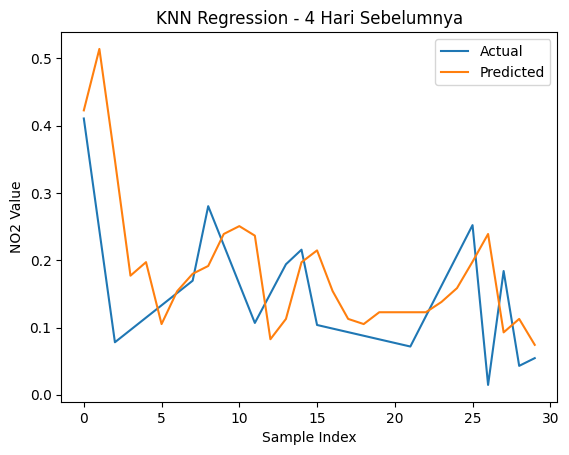

In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

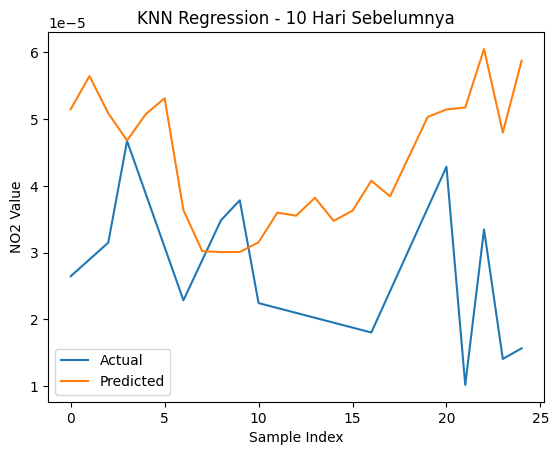

In [45]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()